In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the data
df = pd.read_csv('germany-daily-port-activity-data-and-shipment-estimates.csv')

# Display basic information
print("GERMAN PORT ACTIVITY DATA ANALYSIS: ")
print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['date'].min()} to {df['date'].max()}")
print(f"Number of Unique Ports: {df['portname'].nunique()}")
print(f"Columns: {df.columns.tolist()}")

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Basic statistics
print("\nBASIC STATISTICS: ")
print("Numerical Columns Summary:")
print(df[['portcalls', 'import_cargo', 'export_cargo', 'import', 'export']].describe())

GERMAN PORT ACTIVITY DATA ANALYSIS: 
Dataset Shape: (50749, 29)
Date Range: 2019-01-01 00:00:00+00:00 to 2026-04-24 00:00:00+00:00
Number of Unique Ports: 19
Columns: ['portid', 'portname', 'country', 'ISO3', 'portcalls_container', 'portcalls_dry_bulk', 'portcalls_general_cargo', 'portcalls_roro', 'portcalls_tanker', 'portcalls_cargo', 'portcalls', 'import_container', 'import_dry_bulk', 'import_general_cargo', 'import_roro', 'import_tanker', 'import_cargo', 'import', 'export_container', 'export_dry_bulk', 'export_general_cargo', 'export_roro', 'export_tanker', 'export_cargo', 'export', 'date', 'year', 'month', 'day']

BASIC STATISTICS: 
Numerical Columns Summary:
          portcalls   import_cargo   export_cargo         import  \
count  50749.000000   50749.000000   50749.000000   50749.000000   
mean       3.786518   17271.934166   14303.375180   23406.843563   
std        4.903207   52512.738465   43843.178904   60059.568409   
min        0.000000       0.000000       0.000000       

# 1. TOP PORTS ANALYSIS - Port Calls:
### TOP 10 PORTS BY TOTAL PORT CALLS:

In [42]:
port_calls = df.groupby('portname').agg({
    'portcalls': 'sum',
    'portcalls_container': 'sum',
    'portcalls_dry_bulk': 'sum',
    'portcalls_tanker': 'sum',
    'portcalls_roro': 'sum',
    'portcalls_general_cargo': 'sum'
}).round(2).sort_values('portcalls', ascending=False).head(10)

print(port_calls)

                   portcalls  portcalls_container  portcalls_dry_bulk  \
portname                                                                
Hamburg                49049                25764                2897   
Bremerhaven            33225                19331                 259   
Brunsbuettel           19123                 3018                1362   
Rostock                15601                 1854                1211   
Wilhelmshaven           9117                 3719                 373   
Stade                   8799                 2006                 488   
Lubeck-Travemunde       8743                  636                 136   
Bremen                  8063                  475                1007   
Emden                   7445                  310                 213   
Cuxhaven                7254                  454                  89   

                   portcalls_tanker  portcalls_roro  portcalls_general_cargo  
portname                                    

# 2. TOP PORTS BY CARGO VOLUME
### TOP 10 PORTS BY TOTAL CARGO VOLUME (Import + Export)

In [43]:
port_cargo = df.groupby('portname').agg({
    'import_cargo': 'sum',
    'export_cargo': 'sum'
}).round(2)
port_cargo['total_cargo'] = port_cargo['import_cargo'] + port_cargo['export_cargo']
port_cargo = port_cargo.sort_values('total_cargo', ascending=False).head(10)
print(port_cargo)

               import_cargo  export_cargo  total_cargo
portname                                              
Hamburg           487172281     394203784    881376065
Bremerhaven       205406607     229118247    434524854
Wilhelmshaven      29937314      14605116     44542430
Rostock            17050305      25505692     42555997
Brunsbuettel       27852314       6893736     34746050
Stade              22033735       8066758     30100493
Brake              20528528       8620212     29148740
Bremen             15251182      12775908     28027090
Nordenham          16835794       2620252     19456046
Emden               8614063       4143553     12757616


# 3. TIME SERIES ANALYSIS - Daily Total Activity

In [44]:
# Aggregate daily totals
daily_totals = df.groupby('date').agg({
    'portcalls': 'sum',
    'import_cargo': 'sum',
    'export_cargo': 'sum'
}).reset_index()

daily_totals['total_cargo'] = daily_totals['import_cargo'] + daily_totals['export_cargo']

print(f"Average Daily Port Calls: {daily_totals['portcalls'].mean():.0f}")
print(f"Average Daily Import Cargo: {daily_totals['import_cargo'].mean():.0f} tons")
print(f"Average Daily Export Cargo: {daily_totals['export_cargo'].mean():.0f} tons")
print(f"Peak Day for Port Calls: {daily_totals.loc[daily_totals['portcalls'].idxmax(), 'date'].date()} ({daily_totals['portcalls'].max():.0f} calls)")
print(f"Peak Day for Cargo: {daily_totals.loc[daily_totals['total_cargo'].idxmax(), 'date'].date()} ({daily_totals['total_cargo'].max():.0f} tons)")

Average Daily Port Calls: 72
Average Daily Import Cargo: 328167 tons
Average Daily Export Cargo: 271764 tons
Peak Day for Port Calls: 2021-01-03 (193 calls)
Peak Day for Cargo: 2021-01-03 (2106211 tons)


# 4. VISUALIZATION 1: Top Ports by Port Calls

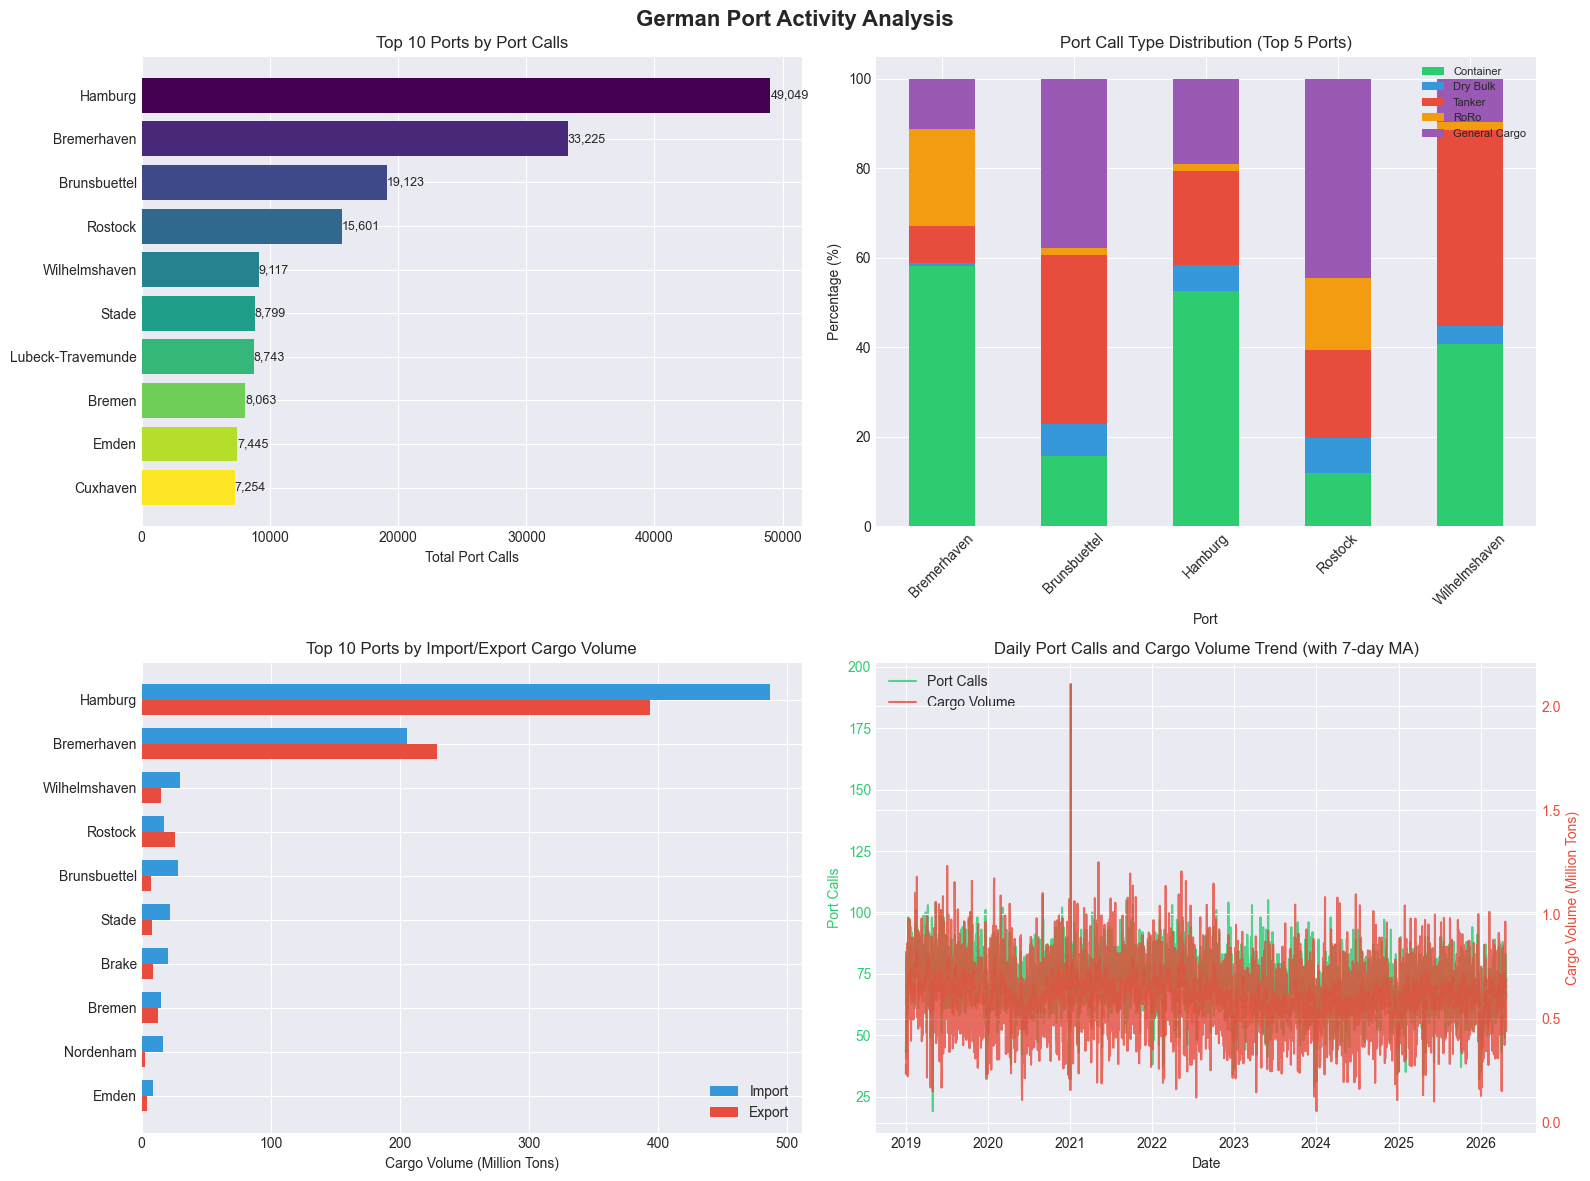

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('German Port Activity Analysis', fontsize=16, fontweight='bold')

# Subplot 1: Top 10 Ports by Port Calls
ax1 = axes[0, 0]
top_ports = port_calls.head(10)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_ports)))
bars = ax1.barh(range(len(top_ports)), top_ports['portcalls'].values, color=colors)
ax1.set_yticks(range(len(top_ports)))
ax1.set_yticklabels(top_ports.index)
ax1.set_xlabel('Total Port Calls')
ax1.set_title('Top 10 Ports by Port Calls')
ax1.invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_ports['portcalls'].values)):
    ax1.text(val + 10, bar.get_y() + bar.get_height()/2, f'{int(val):,}', 
             va='center', fontsize=9)

# Subplot 2: Port Call Type Distribution for Top 5 Ports
ax2 = axes[0, 1]
top5_ports = port_calls.head(5).index
type_cols = ['portcalls_container', 'portcalls_dry_bulk', 'portcalls_tanker', 
             'portcalls_roro', 'portcalls_general_cargo']
type_labels = ['Container', 'Dry Bulk', 'Tanker', 'RoRo', 'General Cargo']

type_data = df[df['portname'].isin(top5_ports)].groupby('portname')[type_cols].sum()
type_data_pct = type_data.div(type_data.sum(axis=1), axis=0) * 100

type_data_pct.plot(kind='bar', stacked=True, ax=ax2, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6'])
ax2.set_xlabel('Port')
ax2.set_ylabel('Percentage (%)')
ax2.set_title('Port Call Type Distribution (Top 5 Ports)')
ax2.legend(type_labels, loc='upper right', fontsize=8)
ax2.tick_params(axis='x', rotation=45)

# Subplot 3: Top 10 Ports by Cargo Volume
ax3 = axes[1, 0]
top_cargo = port_cargo.head(10)
colors_cargo = plt.cm.plasma(np.linspace(0, 1, len(top_cargo)))
x = np.arange(len(top_cargo))
width = 0.35

bars1 = ax3.barh(x - width/2, top_cargo['import_cargo'].values / 1e6, width, label='Import', color='#3498db')
bars2 = ax3.barh(x + width/2, top_cargo['export_cargo'].values / 1e6, width, label='Export', color='#e74c3c')

ax3.set_yticks(x)
ax3.set_yticklabels(top_cargo.index)
ax3.set_xlabel('Cargo Volume (Million Tons)')
ax3.set_title('Top 10 Ports by Import/Export Cargo Volume')
ax3.legend()
ax3.invert_yaxis()

# Subplot 4: Daily Activity Trend
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()

# Plot port calls on primary axis
line1, = ax4.plot(daily_totals['date'], daily_totals['portcalls'], 
                   color='#2ecc71', linewidth=1.5, alpha=0.8, label='Port Calls')
ax4.set_xlabel('Date')
ax4.set_ylabel('Port Calls', color='#2ecc71')
ax4.tick_params(axis='y', labelcolor='#2ecc71')

# Plot cargo on secondary axis
line2, = ax4_twin.plot(daily_totals['date'], daily_totals['total_cargo'] / 1e6, 
                        color='#e74c3c', linewidth=1.5, alpha=0.8, label='Cargo Volume')
ax4_twin.set_ylabel('Cargo Volume (Million Tons)', color='#e74c3c')
ax4_twin.tick_params(axis='y', labelcolor='#e74c3c')

# Add rolling averages
rolling_calls = daily_totals['portcalls'].rolling(window=7, min_periods=1).mean()
rolling_cargo = (daily_totals['total_cargo'] / 1e6).rolling(window=7, min_periods=1).mean()

ax4.plot(daily_totals['date'], rolling_calls, color='#2ecc71', linewidth=2, alpha=0.5, linestyle='--')
ax4_twin.plot(daily_totals['date'], rolling_cargo, color='#e74c3c', linewidth=2, alpha=0.5, linestyle='--')

ax4.set_title('Daily Port Calls and Cargo Volume Trend (with 7-day MA)')
ax4.legend([line1, line2], ['Port Calls', 'Cargo Volume'], loc='upper left')

plt.tight_layout()
plt.savefig('port_activity_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. TRADE BALANCE ANALYSIS (Import vs Export)

In [ ]:
# Calculate trade balance for each port
port_trade = df.groupby('portname').agg({
    'import_cargo': 'sum',
    'export_cargo': 'sum'
}).round(2)

port_trade['trade_balance'] = port_trade['export_cargo'] - port_trade['import_cargo']
port_trade['balance_ratio'] = (port_trade['export_cargo'] / port_trade['import_cargo'] * 100).round(1)

# Export-oriented ports (more exports than imports)
export_oriented = port_trade[port_trade['trade_balance'] > 0].sort_values('trade_balance', ascending=False).head(10)
print("\nTop 10 Export-Oriented Ports:")
print(export_oriented[['import_cargo', 'export_cargo', 'trade_balance', 'balance_ratio']])

# Import-oriented ports (more imports than exports)
import_oriented = port_trade[port_trade['trade_balance'] < 0].sort_values('trade_balance', ascending=True).head(10)
print("\nTop 10 Import-Oriented Ports:")
print(import_oriented[['import_cargo', 'export_cargo', 'trade_balance', 'balance_ratio']])

# Overall trade balance
total_import = port_trade['import_cargo'].sum()
total_export = port_trade['export_cargo'].sum()
print(f"\nOverall German Ports Trade Balance:")
print(f"Total Import: {total_import:,.0f} tons")
print(f"Total Export: {total_export:,.0f} tons")
print(f"Trade Balance: {(total_export - total_import):,.0f} tons")


TRADE BALANCE ANALYSIS (Import vs Export)

Top 10 Export-Oriented Ports:
             import_cargo  export_cargo  trade_balance  balance_ratio
portname                                                             
Bremerhaven     205406607     229118247       23711640          111.5
Rostock          17050305      25505692        8455387          149.6
Sassnitz          1682752       5029194        3346442          298.9
Cuxhaven          2793182       3509478         716296          125.6
Stralsund          696879       1303247         606368          187.0
Wismar            3504400       4004205         499805          114.3
Wischhafen             23            38             15          165.2

Top 10 Import-Oriented Ports:
                   import_cargo  export_cargo  trade_balance  balance_ratio
portname                                                                   
Hamburg               487172281     394203784      -92968497           80.9
Brunsbuettel           27852314      

# 6. VISUALIZATION 2: Trade Balance Heatmap

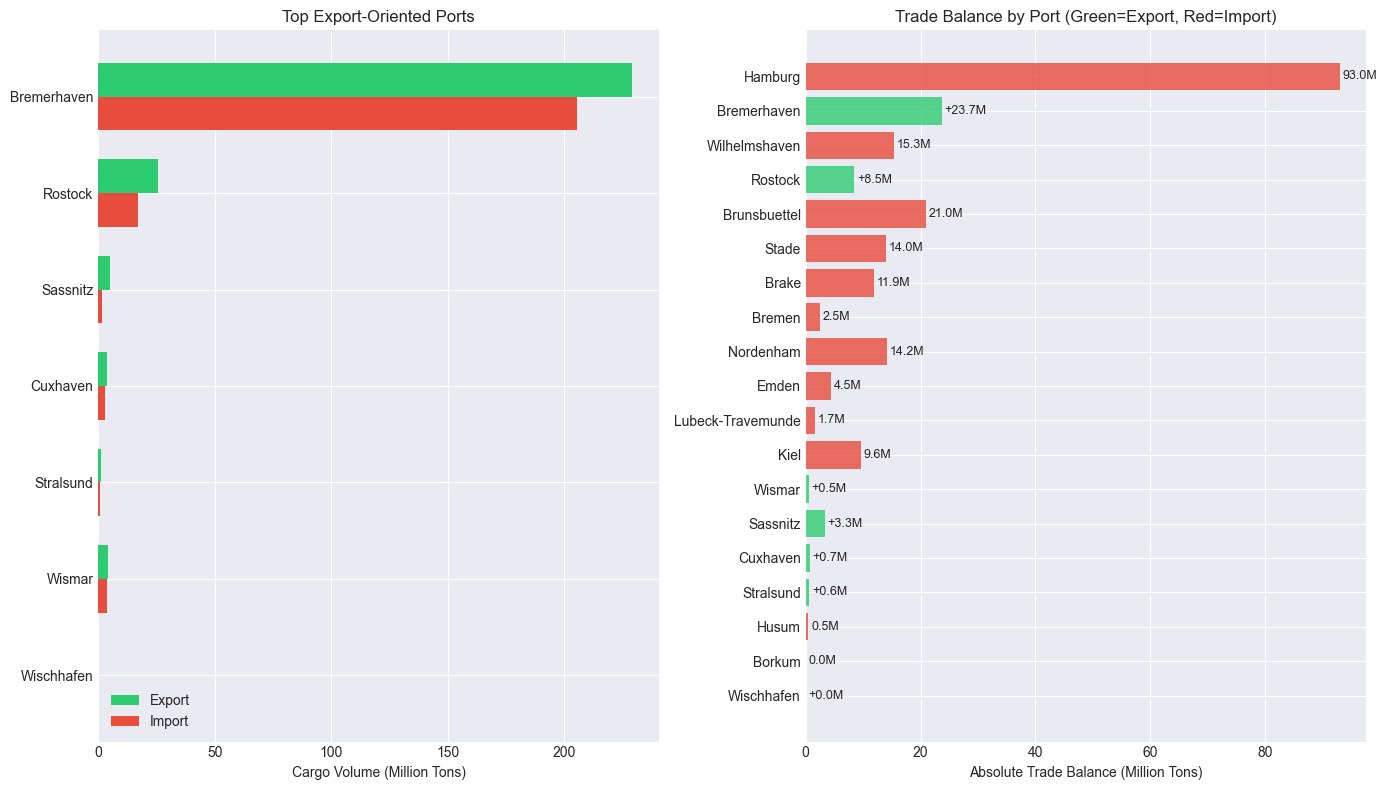

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Subplot 1: Top Export vs Import Ports
ax1 = axes[0]
top_export = export_oriented.head(8)
top_import = import_oriented.head(8)

x = np.arange(len(top_export))
width = 0.35

bars1 = ax1.barh(x - width/2, top_export['export_cargo'].values / 1e6, width, label='Export', color='#2ecc71')
bars2 = ax1.barh(x + width/2, top_export['import_cargo'].values / 1e6, width, label='Import', color='#e74c3c')

ax1.set_yticks(x)
ax1.set_yticklabels(top_export.index)
ax1.set_xlabel('Cargo Volume (Million Tons)')
ax1.set_title('Top Export-Oriented Ports')
ax1.legend()
ax1.invert_yaxis()

# Subplot 2: Trade Balance Heatmap
ax2 = axes[1]

# FIRST, create the total_cargo column
port_trade['total_cargo'] = port_trade['import_cargo'] + port_trade['export_cargo']

# Get top ports by total cargo
top_ports_by_cargo = port_trade.nlargest(20, 'total_cargo').index
balance_matrix = port_trade.loc[top_ports_by_cargo, ['trade_balance']].copy()
balance_matrix['trade_balance_mt'] = balance_matrix['trade_balance'] / 1e6

# Create color map
colors = balance_matrix['trade_balance_mt'].apply(
    lambda x: '#2ecc71' if x > 0 else '#e74c3c' if x < 0 else '#3498db'
)

bars = ax2.barh(range(len(balance_matrix)), balance_matrix['trade_balance_mt'].abs().values, 
                color=colors, alpha=0.8)
ax2.set_yticks(range(len(balance_matrix)))
ax2.set_yticklabels(balance_matrix.index)
ax2.set_xlabel('Absolute Trade Balance (Million Tons)')
ax2.set_title('Trade Balance by Port (Green=Export, Red=Import)')
ax2.invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, balance_matrix['trade_balance_mt'].values)):
    sign = '+' if val > 0 else ''
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{sign}{abs(val):.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('trade_balance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 7. VESSEL TYPE ANALYSIS


In [47]:
vessel_types = {
    'Container': 'portcalls_container',
    'Dry Bulk': 'portcalls_dry_bulk',
    'Tanker': 'portcalls_tanker',
    'RoRo': 'portcalls_roro',
    'General Cargo': 'portcalls_general_cargo'
}

vessel_summary = {}
for name, col in vessel_types.items():
    total = df[col].sum()
    ports_with = (df[df[col] > 0]['portname'].nunique())
    vessel_summary[name] = {'total_calls': total, 'ports_with_activity': ports_with}

vessel_df = pd.DataFrame(vessel_summary).T
print(vessel_df)

# Monthly trend by vessel type
df['month'] = df['date'].dt.to_period('M')
monthly_vessel = df.groupby('month')[list(vessel_types.values())].sum()
monthly_vessel.index = monthly_vessel.index.astype(str)

print("\nMonthly Vessel Calls Trend (Last 6 months):")
print(monthly_vessel.tail(6))

               total_calls  ports_with_activity
Container            59608                   17
Dry Bulk              9846                   16
Tanker               42260                   18
RoRo                 25870                   16
General Cargo        54578                   19

Monthly Vessel Calls Trend (Last 6 months):
         portcalls_container  portcalls_dry_bulk  portcalls_tanker  \
month                                                                
2025-11                  676                 117               462   
2025-12                  624                 113               434   
2026-01                  597                  82               412   
2026-02                  618                  99               369   
2026-03                  655                 109               443   
2026-04                  516                  94               357   

         portcalls_roro  portcalls_general_cargo  
month                                             
2025

# 8. VISUALIZATION 3: Vessel Type Analysis


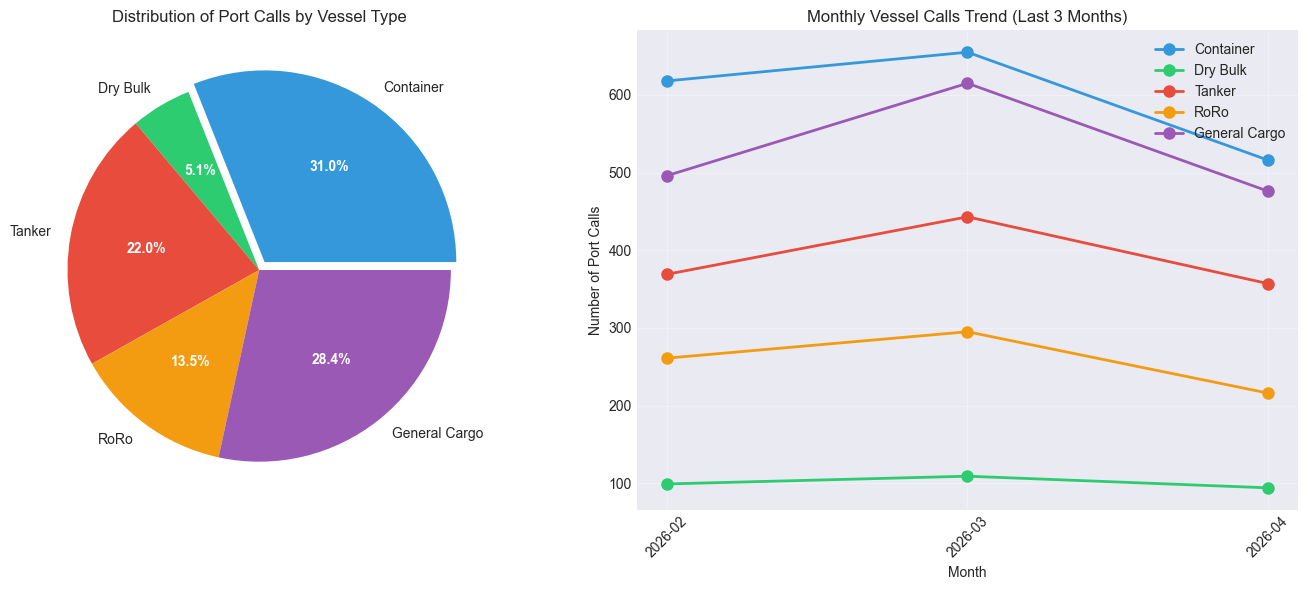

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Vessel Type Distribution (Pie Chart)
ax1 = axes[0]
vessel_totals = vessel_df['total_calls'].values
vessel_labels = vessel_df.index.tolist()
colors_pie = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

wedges, texts, autotexts = ax1.pie(vessel_totals, labels=vessel_labels, autopct='%1.1f%%',
                                    colors=colors_pie, explode=[0.05, 0, 0, 0, 0])
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax1.set_title('Distribution of Port Calls by Vessel Type')

# Subplot 2: Monthly Trend (Last 3 months)
ax2 = axes[1]
last_3_months = monthly_vessel.tail(3)
for i, (name, col) in enumerate(vessel_types.items()):
    ax2.plot(range(len(last_3_months)), last_3_months[col].values, 
             marker='o', label=name, color=colors_pie[i], linewidth=2, markersize=8)

ax2.set_xticks(range(len(last_3_months)))
ax2.set_xticklabels(last_3_months.index, rotation=45)
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Port Calls')
ax2.set_title('Monthly Vessel Calls Trend (Last 3 Months)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vessel_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 9. CARGO TYPE ANALYSIS (CORRECTED)


In [48]:
# Define cargo types with their correct column names
cargo_types = {
    'Container': ('import_container', 'export_container'),
    'Dry Bulk': ('import_dry_bulk', 'export_dry_bulk'),
    'General Cargo': ('import_general_cargo', 'export_general_cargo'),
    'RoRo': ('import_roro', 'export_roro'),
    'Tanker': ('import_tanker', 'export_tanker')
}

cargo_summary = {}
for name, (import_col, export_col) in cargo_types.items():
    import_total = df[import_col].sum()
    export_total = df[export_col].sum()
    
    cargo_summary[name] = {
        'import_tons': import_total,
        'export_tons': export_total,
        'total_tons': import_total + export_total
    }

cargo_df = pd.DataFrame(cargo_summary).T
print(cargo_df.round(0))

# Identify dominant cargo type at each major port
print("\nDominant Cargo Type at Major Ports:")
major_ports = port_cargo.head(10).index.tolist()

for port in major_ports:
    port_cargo_types = {}
    for name, (import_col, export_col) in cargo_types.items():
        # Sum both import and export for this cargo type at this port
        port_cargo_types[name] = df[df['portname'] == port][[import_col, export_col]].sum().sum()
    
    dominant = max(port_cargo_types, key=port_cargo_types.get)
    total = sum(port_cargo_types.values())
    percentage = (port_cargo_types[dominant] / total * 100) if total > 0 else 0
    print(f"  {port}: {dominant} ({percentage:.1f}% of total cargo)")

               import_tons  export_tons  total_tons
Container        585980726    604799995  1190780721
Dry Bulk         236666960     63447694   300114654
General Cargo     39100464     36964145    76064609
RoRo              14777752     20662943    35440695
Tanker           311334675     67097028   378431703

Dominant Cargo Type at Major Ports:
  Hamburg: Container (76.1% of total cargo)
  Bremerhaven: Container (93.5% of total cargo)
  Wilhelmshaven: Tanker (77.7% of total cargo)
  Rostock: Tanker (49.3% of total cargo)
  Brunsbuettel: Tanker (57.7% of total cargo)
  Stade: Dry Bulk (40.3% of total cargo)
  Brake: Dry Bulk (67.2% of total cargo)
  Bremen: Dry Bulk (47.8% of total cargo)
  Nordenham: Dry Bulk (49.8% of total cargo)
  Emden: Tanker (31.2% of total cargo)


# 10. VISUALIZATION 4: Cargo Type Distribution


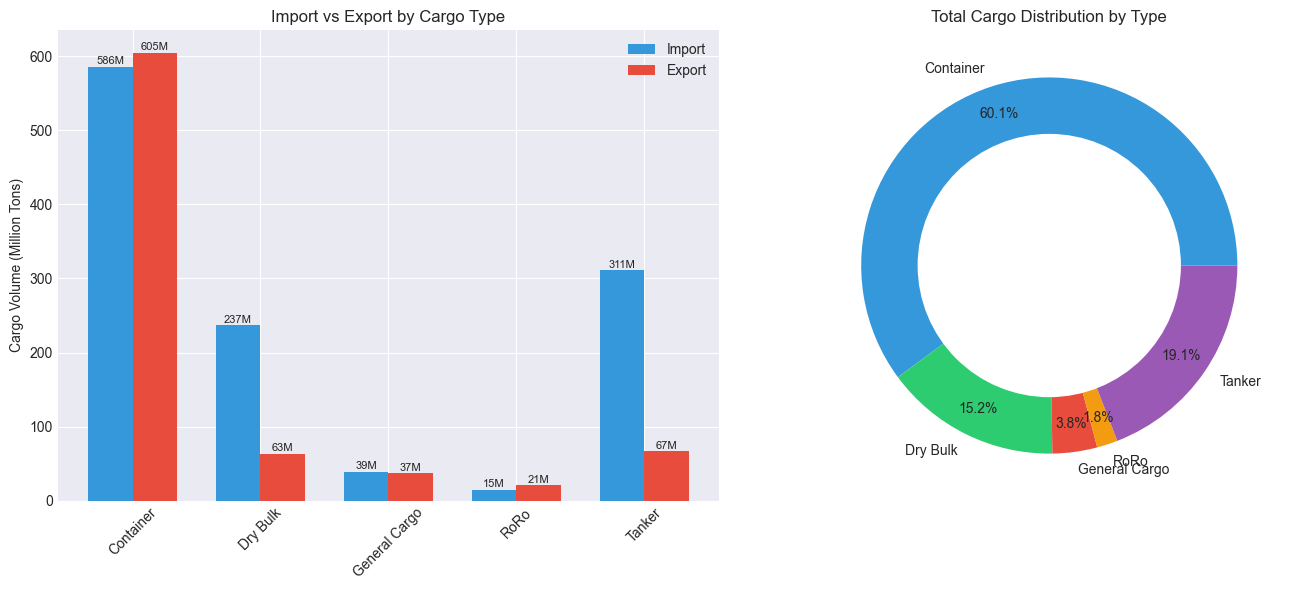

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Cargo Type Distribution (Stacked Bar)
ax1 = axes[0]
cargo_import = [cargo_df.loc[t, 'import_tons'] / 1e6 for t in cargo_df.index]
cargo_export = [cargo_df.loc[t, 'export_tons'] / 1e6 for t in cargo_df.index]
x = np.arange(len(cargo_df.index))
width = 0.35

bars1 = ax1.bar(x - width/2, cargo_import, width, label='Import', color='#3498db')
bars2 = ax1.bar(x + width/2, cargo_export, width, label='Export', color='#e74c3c')

ax1.set_xticks(x)
ax1.set_xticklabels(cargo_df.index, rotation=45)
ax1.set_ylabel('Cargo Volume (Million Tons)')
ax1.set_title('Import vs Export by Cargo Type')
ax1.legend()

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.0f}M', ha='center', va='bottom', fontsize=8)

# Subplot 2: Cargo Type Share (Donut Chart)
ax2 = axes[1]
total_by_type = cargo_df['total_tons'].values
colors_donut = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

wedges, texts, autotexts = ax2.pie(total_by_type, labels=cargo_df.index, autopct='%1.1f%%',
                                    colors=colors_donut, pctdistance=0.85)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
ax2.set_title('Total Cargo Distribution by Type')

plt.tight_layout()
plt.savefig('cargo_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 11. BUSIEST DAYS OF WEEK ANALYSIS


In [49]:
df['day_of_week'] = df['date'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=weekday_order, ordered=True)

weekly_pattern = df.groupby('day_of_week').agg({
    'portcalls': 'mean',
    'import_cargo': 'mean',
    'export_cargo': 'mean'
}).round(0)

print("Average Daily Activity by Day of Week:")
print(weekly_pattern)

# Identify busiest day
busiest_day = weekly_pattern['portcalls'].idxmax()
print(f"\nBusiest Day: {busiest_day} (Avg {weekly_pattern.loc[busiest_day, 'portcalls']:.0f} port calls)")

# Identify weekend vs weekday
weekday_avg = weekly_pattern[weekly_pattern.index.isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])]['portcalls'].mean()
weekend_avg = weekly_pattern[weekly_pattern.index.isin(['Saturday', 'Sunday'])]['portcalls'].mean()
print(f"Weekday Average Port Calls: {weekday_avg:.0f}")
print(f"Weekend Average Port Calls: {weekend_avg:.0f}")
print(f"Weekday is {weekday_avg/weekend_avg:.1f}x busier than weekend")

Average Daily Activity by Day of Week:
             portcalls  import_cargo  export_cargo
day_of_week                                       
Monday             4.0       20088.0       14366.0
Tuesday            4.0       18705.0       14616.0
Wednesday          4.0       17697.0       13992.0
Thursday           4.0       17015.0       14528.0
Friday             4.0       16476.0       14243.0
Saturday           3.0       14698.0       14315.0
Sunday             3.0       16223.0       14062.0

Busiest Day: Monday (Avg 4 port calls)
Weekday Average Port Calls: 4
Weekend Average Port Calls: 3
Weekday is 1.3x busier than weekend


# 12. VISUALIZATION 5: Weekly Pattern and Port Performance


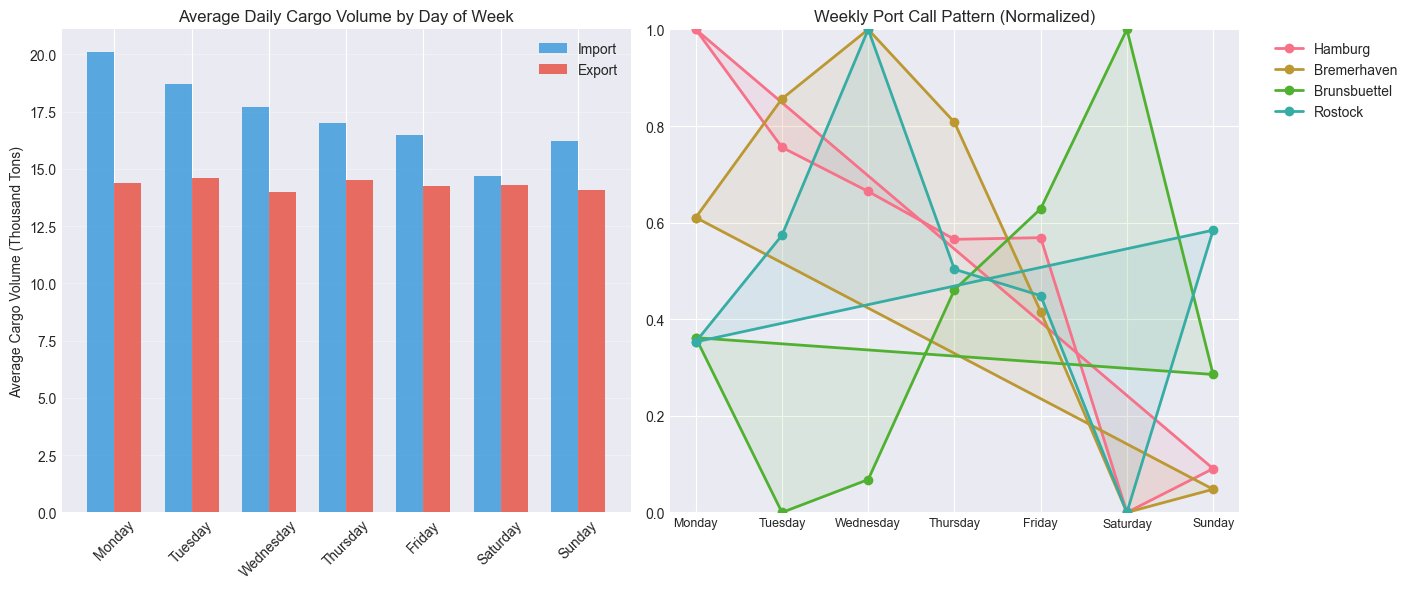

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Weekly Pattern
ax1 = axes[0]
x = range(len(weekly_pattern))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], weekly_pattern['import_cargo'].values / 1e3, 
                width, label='Import', color='#3498db', alpha=0.8)
bars2 = ax1.bar([i + width/2 for i in x], weekly_pattern['export_cargo'].values / 1e3, 
                width, label='Export', color='#e74c3c', alpha=0.8)

ax1.set_xticks(x)
ax1.set_xticklabels(weekly_pattern.index, rotation=45)
ax1.set_ylabel('Average Cargo Volume (Thousand Tons)')
ax1.set_title('Average Daily Cargo Volume by Day of Week')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Subplot 2: Port Calls Radar Chart for Top 5 Ports
ax2 = axes[1]
top5_ports = port_calls.head(5).index.tolist()
weekday_port_calls = df[df['portname'].isin(top5_ports)].groupby(['portname', 'day_of_week'])['portcalls'].mean().unstack()

# Normalize for radar chart
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
normalized_data = pd.DataFrame(scaler.fit_transform(weekday_port_calls.T).T, 
                                columns=weekday_port_calls.columns, 
                                index=weekday_port_calls.index)

# Create radar chart
angles = np.linspace(0, 2 * np.pi, len(weekday_order), endpoint=False).tolist()
angles += angles[:1]

for i, port in enumerate(top5_ports[:4]):  # Limit to 4 for clarity
    values = normalized_data.loc[port].values.tolist()
    values += values[:1]
    ax2.plot(angles, values, 'o-', linewidth=2, label=port)
    ax2.fill(angles, values, alpha=0.1)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(weekday_order, fontsize=9)
ax2.set_ylim(0, 1)
ax2.set_title('Weekly Port Call Pattern (Normalized)')
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
ax2.grid(True)

plt.tight_layout()
plt.savefig('weekly_pattern_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 13. CORRELATION ANALYSIS


In [50]:
# Select key numerical columns for correlation
correlation_cols = ['portcalls_container', 'portcalls_dry_bulk', 'portcalls_tanker',
                    'portcalls_roro', 'portcalls_general_cargo', 'portcalls',
                    'import_cargo', 'export_cargo', 'import', 'export']

correlation_matrix = df[correlation_cols].corr()

# Display correlations with portcalls
print("Correlation with Total Port Calls:")
for col in correlation_cols:
    if col != 'portcalls':
        print(f"  {col}: {correlation_matrix.loc['portcalls', col]:.3f}")

print("\nCorrelation between Import and Export Cargo:", 
      f"{correlation_matrix.loc['import_cargo', 'export_cargo']:.3f}")

Correlation with Total Port Calls:
  portcalls_container: 0.890
  portcalls_dry_bulk: 0.465
  portcalls_tanker: 0.702
  portcalls_roro: 0.357
  portcalls_general_cargo: 0.634
  import_cargo: 0.750
  export_cargo: 0.767
  import: 0.743
  export: 0.782

Correlation between Import and Export Cargo: 0.664


# 14. SUMMARY REPORT


In [51]:
print(f"""
KEY FINDINGS:
------------
1. MAJOR PORTS:
   • Hamburg is the dominant port with {port_calls.loc['Hamburg', 'portcalls']:.0f} total port calls
   • Bremerhaven ranks second with {port_calls.loc['Bremerhaven', 'portcalls']:.0f} calls
   • These two ports handle over {((port_calls.loc['Hamburg', 'portcalls'] + port_calls.loc['Bremerhaven', 'portcalls']) / port_calls['portcalls'].sum() * 100):.1f}% of all port calls

2. CARGO VOLUME:
   • Total cargo handled: {(total_import + total_export) / 1e9:.2f} billion tons
   • Trade Balance: {(total_export - total_import) / 1e6:+.1f} million tons {'(Export-oriented)' if total_export > total_import else '(Import-oriented)'}

3. VESSEL TYPES:
   • Container vessels dominate with {vessel_df.loc['Container', 'total_calls']:.0f} calls ({vessel_df.loc['Container', 'total_calls'] / vessel_df['total_calls'].sum() * 100:.1f}%)
   • General cargo is second with {vessel_df.loc['General Cargo', 'total_calls']:.0f} calls

4. WEEKLY PATTERNS:
   • {busiest_day} is the busiest day for port activity
   • Weekdays are {weekday_avg/weekend_avg:.1f}x busier than weekends

5. CARGO TYPES:
   • {cargo_df['total_tons'].idxmax()} is the largest cargo type with {cargo_df['total_tons'].max() / 1e9:.2f} billion tons
   • {cargo_df[cargo_df['import_tons'] > cargo_df['export_tons']].index[0]} is the most import-oriented cargo type

RECOMMENDATIONS:
----------------
1. Focus infrastructure investment on Hamburg and Bremerhaven as primary hubs
2. Consider optimizing weekend operations to reduce weekday congestion
3. Continue supporting container infrastructure as dominant cargo type
4. Monitor trade balance trends for strategic planning
""")


KEY FINDINGS:
------------
1. MAJOR PORTS:
   • Hamburg is the dominant port with 49049 total port calls
   • Bremerhaven ranks second with 33225 calls
   • These two ports handle over 49.4% of all port calls

2. CARGO VOLUME:
   • Total cargo handled: 1.60 billion tons
   • Trade Balance: -150.7 million tons (Import-oriented)

3. VESSEL TYPES:
   • Container vessels dominate with 59608 calls (31.0%)
   • General cargo is second with 54578 calls

4. WEEKLY PATTERNS:
   • Monday is the busiest day for port activity
   • Weekdays are 1.3x busier than weekends

5. CARGO TYPES:
   • Container is the largest cargo type with 1.19 billion tons
   • Dry Bulk is the most import-oriented cargo type

RECOMMENDATIONS:
----------------
1. Focus infrastructure investment on Hamburg and Bremerhaven as primary hubs
2. Consider optimizing weekend operations to reduce weekday congestion
3. Continue supporting container infrastructure as dominant cargo type
4. Monitor trade balance trends for strategic 